<a href="https://colab.research.google.com/github/Velan6623/Agricultural_Runoff_Toxcity_Prediction/blob/main/Agricultural_Runoff_Toxcity_level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

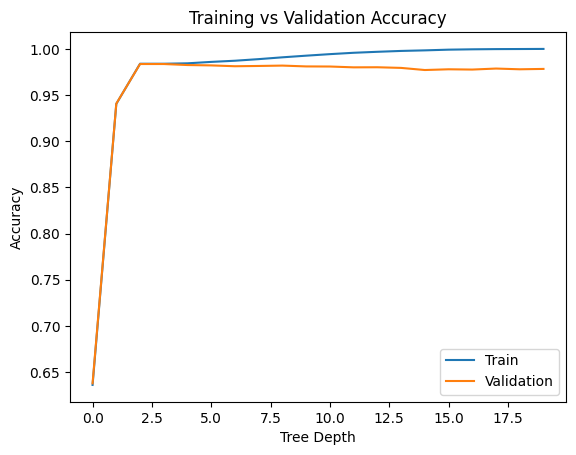

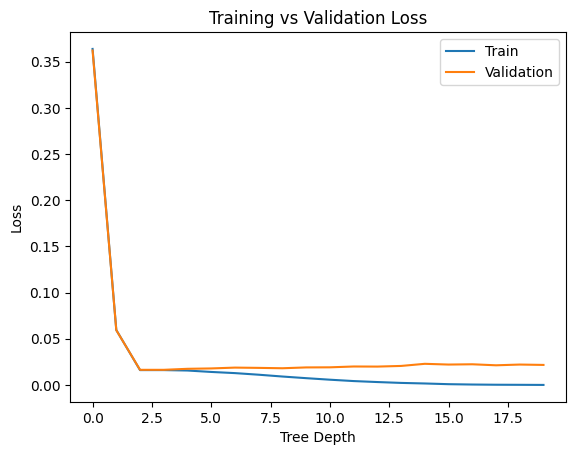


===== Validation METRICS =====
Accuracy : 0.9795
Precision: 0.9795157229876844
Recall   : 0.9795
F1 Score : 0.9795019973120618


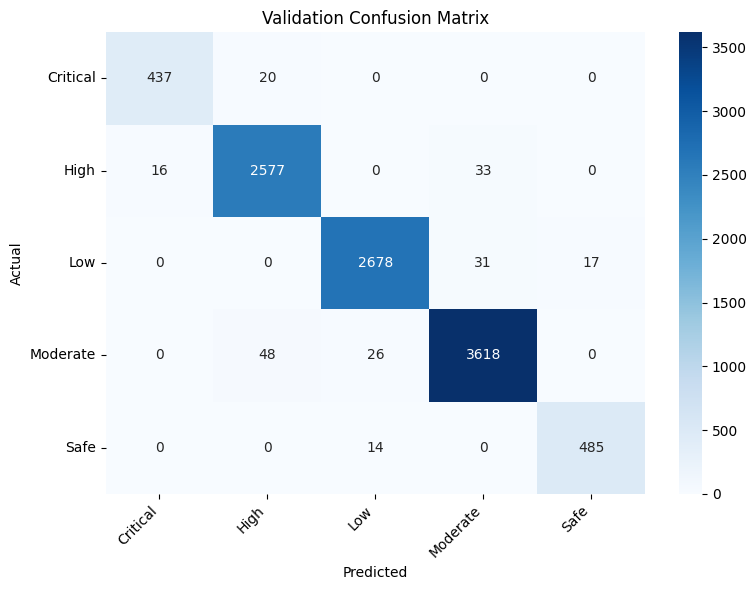

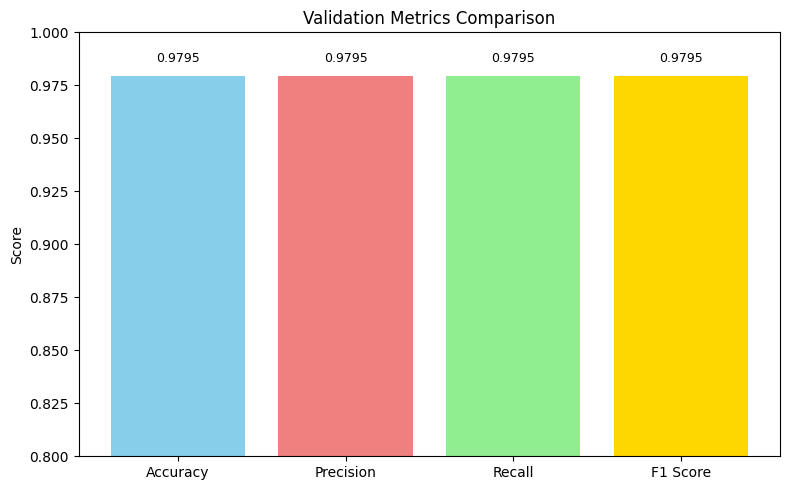


===== Testing METRICS =====
Accuracy : 0.9788
Precision: 0.9788525035974384
Recall   : 0.9788
F1 Score : 0.9788148832355055


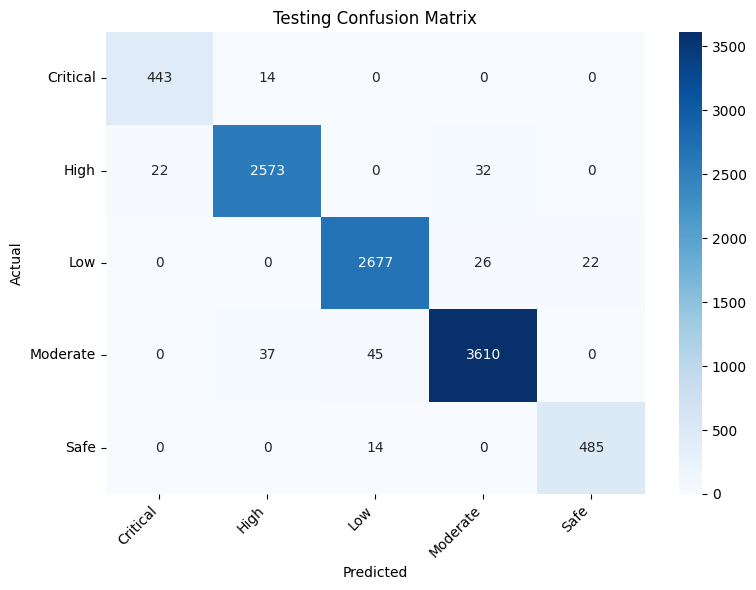

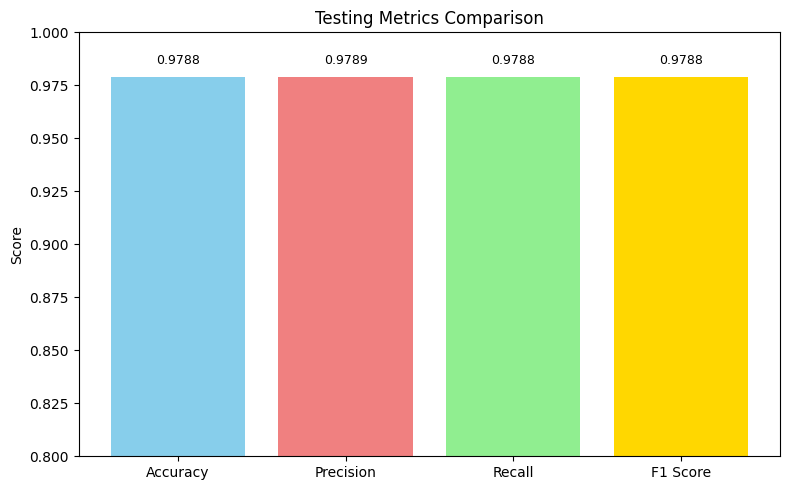

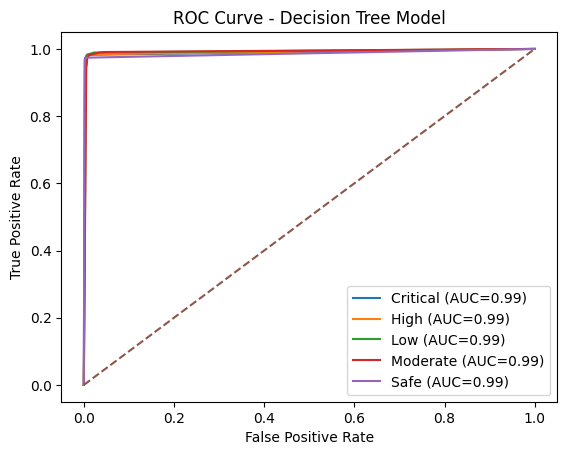

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Added seaborn import

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier

# ==========================================================
# 1. LOAD DATA
# ==========================================================

try:
    data = pd.read_csv("agro_runoff_100000_samples.csv")
except FileNotFoundError:
    print("File not found. Please upload 'agro_runoff_100000_samples.csv' dataset.")
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')
    data = pd.read_csv("agro_runoff_100000_samples.csv")

if "Node_ID" in data.columns:
    data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# ✅ 2. ADD REALISTIC SENSOR NOISE (IMPORTANT)
# ==========================================================

np.random.seed(42)

noise_factor = 0.02   # Recommended 0.01–0.03

noise = np.random.normal(
    loc=0,
    scale=noise_factor,
    size=X.shape
)

X = X + noise

# ==========================================================
# 3. LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Filter out classes with only one sample to avoid ValueError in stratified split
class_counts = pd.Series(y_encoded).value_counts()
single_sample_classes = class_counts[class_counts < 2].index

if not single_sample_classes.empty:
    indices_to_remove = pd.Series(y_encoded)[pd.Series(y_encoded).isin(single_sample_classes)].index
    X = X.drop(indices_to_remove)
    y_encoded = np.delete(y_encoded, indices_to_remove)
    print(f"Removed {len(indices_to_remove)} samples belonging to classes with only one member for stratified split.")

# ==========================================================
# 4. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 5. DATA SPLIT (80-10-10)
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# ==========================================================
# 6. DECISION TREE MODEL
# ==========================================================

model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=5,
    random_state=42
)

# ==========================================================
# 7. TRAINING PERFORMANCE (Depth Simulation)
# ==========================================================

train_acc = []
val_acc = []
train_loss = []
val_loss = []

depth_range = range(1,21)

for d in depth_range:

    temp_model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    temp_model.fit(X_train, y_train)

    train_pred = temp_model.predict(X_train)
    val_pred = temp_model.predict(X_val)

    ta = accuracy_score(y_train, train_pred)
    va = accuracy_score(y_val, val_pred)

    train_acc.append(ta)
    val_acc.append(va)

    train_loss.append(1-ta)
    val_loss.append(1-va)

# ==========================================================
# TRAINING vs VALIDATION ACCURACY
# ==========================================================

plt.figure()
plt.plot(train_acc)
plt.plot(val_acc)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# TRAINING vs VALIDATION LOSS
# ==========================================================

plt.figure()
plt.plot(train_loss)
plt.plot(val_loss)
plt.title("Training vs Validation Loss")
plt.xlabel("Tree Depth")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# Train Final Model
model.fit(X_train, y_train)

# ==========================================================
# COMMON EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X, y_true, title):

    y_prob = model.predict_proba(X)
    y_pred = model.predict(X)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6)) # Adjust figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right') # Rotate and align x-axis labels
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ---------------- Metrics Bar Chart ----------------
    metrics_values=[acc,prec,rec,f1]
    metrics_names=["Accuracy","Precision","Recall","F1 Score"]
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold'] # Different colors for each bar

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metrics_names, metrics_values, color=colors)
    plt.ylim(0.8, 1) # Changed from 0,1 to 0.8,1
    plt.title(f"{title} Metrics Comparison")
    plt.ylabel("Score")

    # Add point labels above each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    return y_true, y_prob


# ==========================================================
# 8. VALIDATION RESULTS
# ==========================================================

val_true, val_prob = evaluate_model(
    X_val, y_val, "Validation"
)

# ==========================================================
# 9. TEST RESULTS
# ==========================================================

test_true, test_prob = evaluate_model(
    X_test, y_test, "Testing"
)

# ==========================================================
# 10. MULTI-CLASS ROC CURVE
# ==========================================================

y_test_bin = label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        test_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Model")
plt.legend()
plt.show()

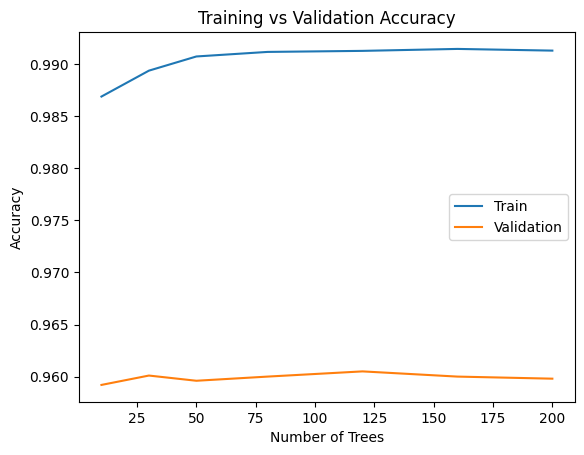

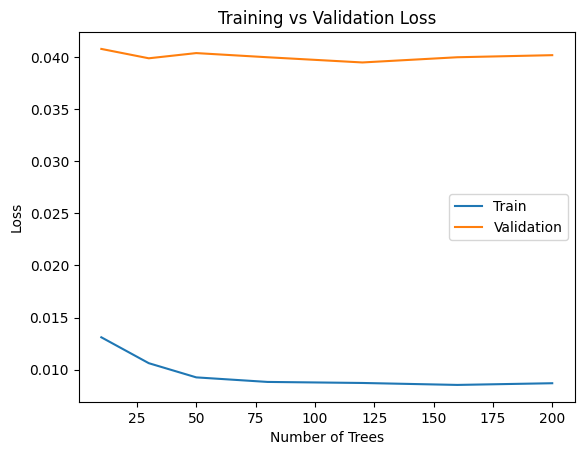


===== Validation METRICS =====
Accuracy : 0.9598
Precision: 0.9598191261491941
Recall   : 0.9598
F1 Score : 0.9597776886512492


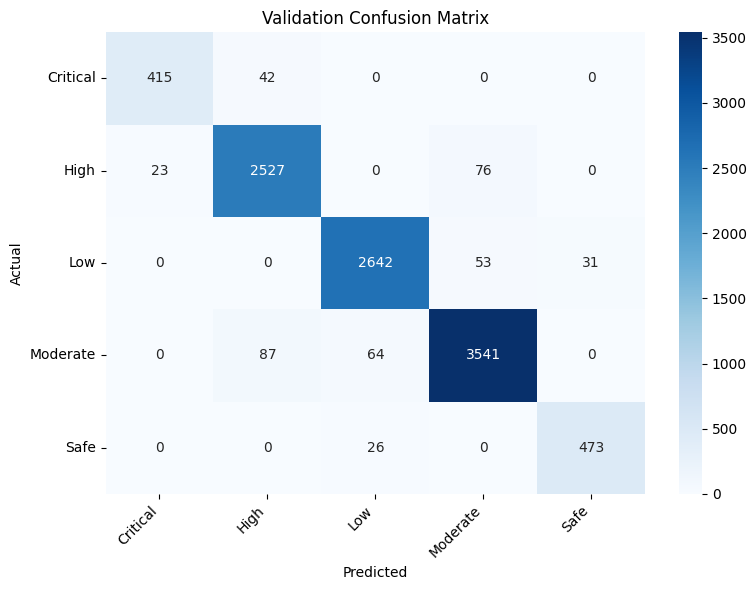

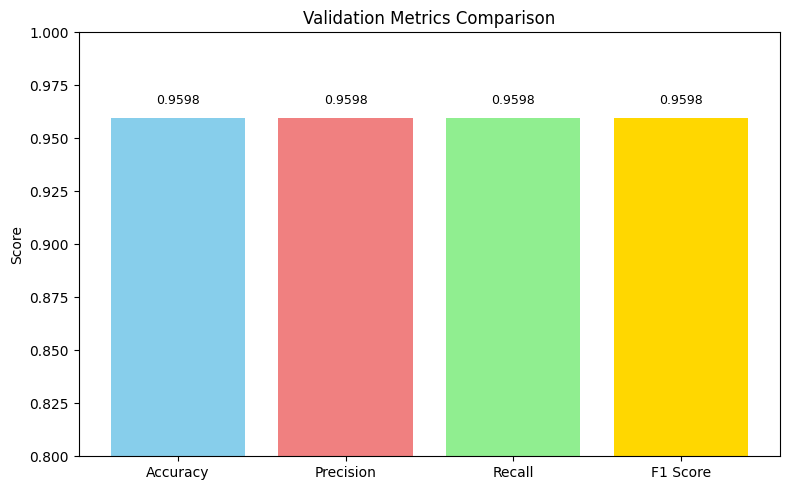


===== Testing METRICS =====
Accuracy : 0.96
Precision: 0.9600044550378629
Recall   : 0.96
F1 Score : 0.9599909845449888


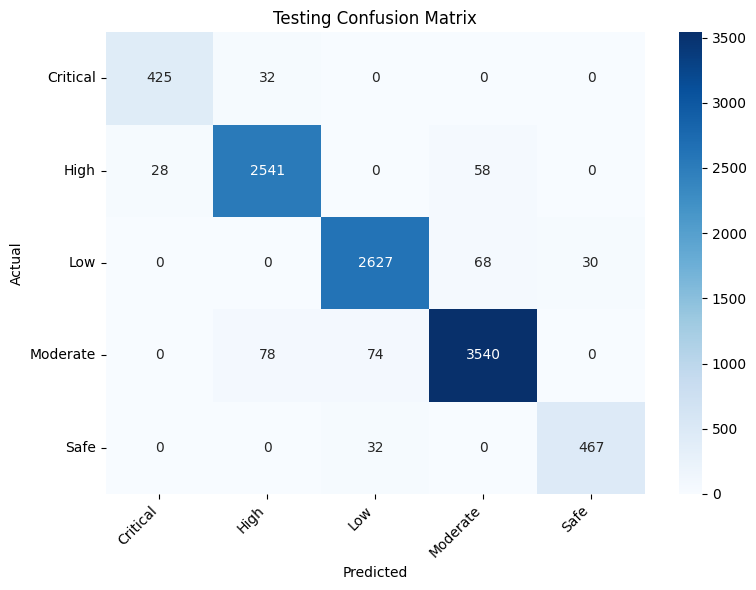

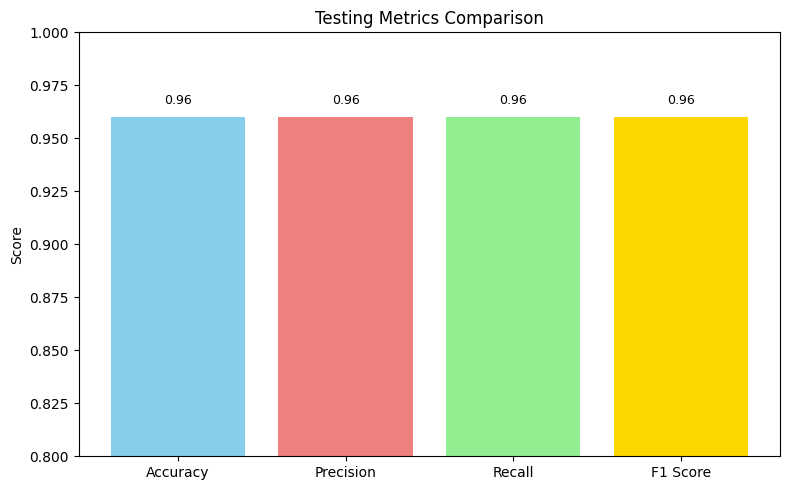

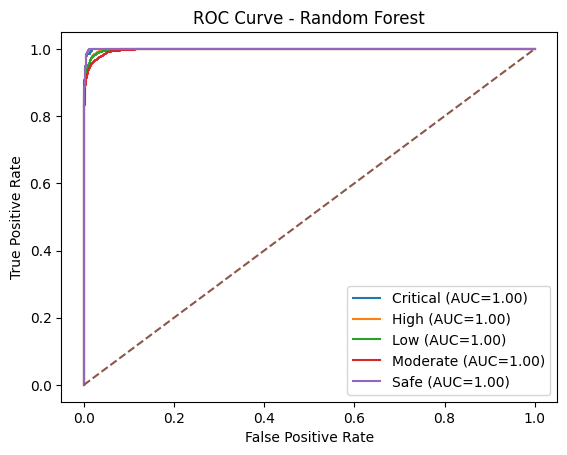

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Added seaborn import

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier

# ==========================================================
# 1. LOAD DATA
# ==========================================================

try:
    data = pd.read_csv("agro_runoff_100000_samples.csv")
except FileNotFoundError:
    print("File not found. Please upload 'agro_runoff_100000_samples.csv' dataset.")
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')
    data = pd.read_csv("agro_runoff_100000_samples.csv")

if "Node_ID" in data.columns:
    data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# ✅ 2. ADD REALISTIC NOISE
# ==========================================================

np.random.seed(42)

noise_factor = 0.05 # Increased noise_factor to 0.05

noise = np.random.normal(
    loc=0,
    scale=noise_factor,
    size=X.shape
)

X = X + noise

# ==========================================================
# 3. LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Filter out classes with only one sample to avoid ValueError in stratified split
class_counts = pd.Series(y_encoded).value_counts()
single_sample_classes = class_counts[class_counts < 2].index

if not single_sample_classes.empty:
    indices_to_remove = pd.Series(y_encoded)[pd.Series(y_encoded).isin(single_sample_classes)].index
    X = X.drop(indices_to_remove)
    y_encoded = np.delete(y_encoded, indices_to_remove)
    print(f"Removed {len(indices_to_remove)} samples belonging to classes with only one member for stratified split.")

# ==========================================================
# 4. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 5. DATA SPLIT (80-10-10)
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# ==========================================================
# 6. RANDOM FOREST MODEL
# ==========================================================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# ==========================================================
# 7. TRAINING PERFORMANCE SIMULATION
# ==========================================================

train_acc=[]
val_acc=[]
train_loss=[]
val_loss=[]

tree_range=[10,30,50,80,120,160,200]

for n in tree_range:

    temp_model = RandomForestClassifier(
        n_estimators=n,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )

    temp_model.fit(X_train,y_train)

    train_pred=temp_model.predict(X_train)
    val_pred=temp_model.predict(X_val)

    ta=accuracy_score(y_train,train_pred)
    va=accuracy_score(y_val,val_pred)

    train_acc.append(ta)
    val_acc.append(va)

    train_loss.append(1-ta)
    val_loss.append(1-va)

# ==========================================================
# TRAINING vs VALIDATION ACCURACY
# ==========================================================

plt.figure()
plt.plot(tree_range,train_acc)
plt.plot(tree_range,val_acc)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# TRAINING vs VALIDATION LOSS
# ==========================================================

plt.figure()
plt.plot(tree_range,train_loss)
plt.plot(tree_range,val_loss)
plt.title("Training vs Validation Loss")
plt.xlabel("Number of Trees")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# Train Final Model
model.fit(X_train,y_train)

# ==========================================================
# COMMON EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X,y_true,title):

    y_prob=model.predict_proba(X)
    y_pred=model.predict(X)

    acc=accuracy_score(y_true,y_pred)
    prec=precision_score(y_true,y_pred,average='weighted')
    rec=recall_score(y_true,y_pred,average='weighted')
    f1=f1_score(y_true,y_pred,average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :",acc)
    print("Precision:",prec)
    print("Recall   :",rec)
    print("F1 Score :",f1)

    # Confusion Matrix
    cm=confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(8, 6)) # Adjust figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Metrics Bar Chart
    metrics_values=[acc,prec,rec,f1]
    metrics_names=["Accuracy","Precision","Recall","F1 Score"]
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold'] # Different colors for each bar

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metrics_names, metrics_values, color=colors)
    plt.ylim(0.8,1)
    plt.title(f"{title} Metrics Comparison")
    plt.ylabel("Score")

    # Add point labels above each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    return y_true,y_prob


# ==========================================================
# 8. VALIDATION RESULTS
# ==========================================================

val_true,val_prob=evaluate_model(
    X_val,y_val,"Validation"
)

# ==========================================================
# 9. TEST RESULTS
# ==========================================================

test_true,test_prob=evaluate_model(
    X_test,y_test,"Testing"
)

# ==========================================================
# 10. MULTI-CLASS ROC CURVE
# ==========================================================

y_test_bin=label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr,tpr,_=roc_curve(
        y_test_bin[:,i],
        test_prob[:,i]
    )

    roc_auc=auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

Training Fast SVM Model...


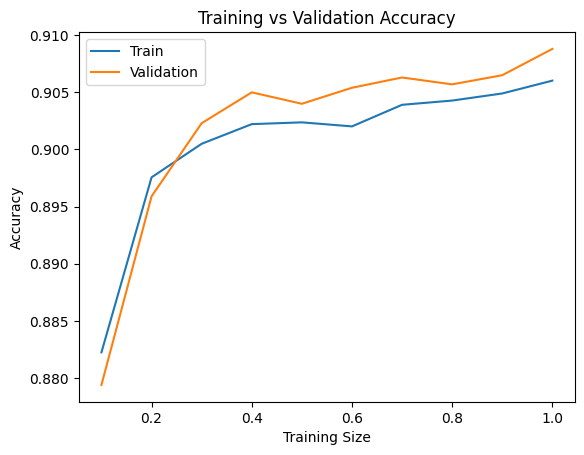


===== Validation METRICS =====
Accuracy : 0.9088
Precision: 0.9167405882967924
Recall   : 0.9088
F1 Score : 0.9078173625308318


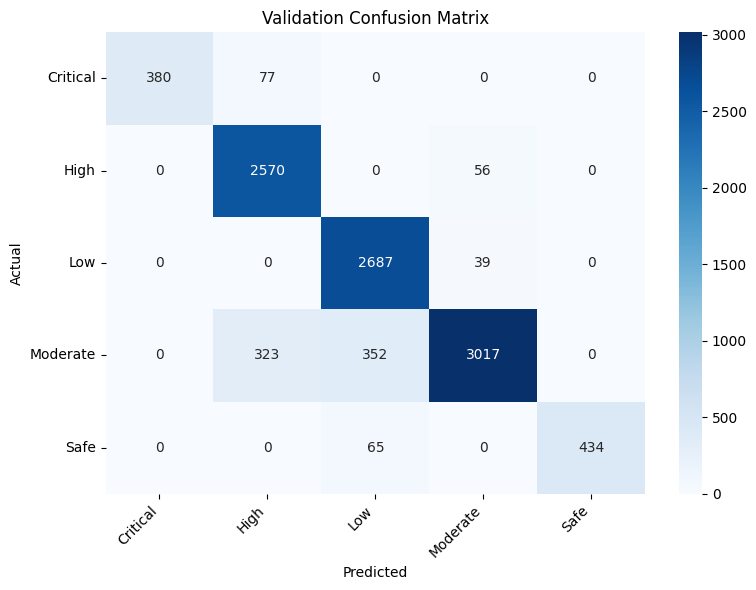

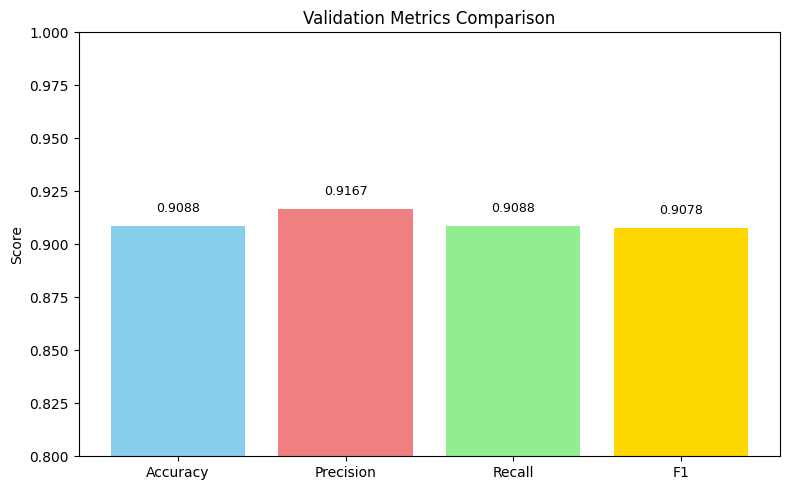


===== Testing METRICS =====
Accuracy : 0.9088
Precision: 0.9157739347988346
Recall   : 0.9088
F1 Score : 0.9079155925644338


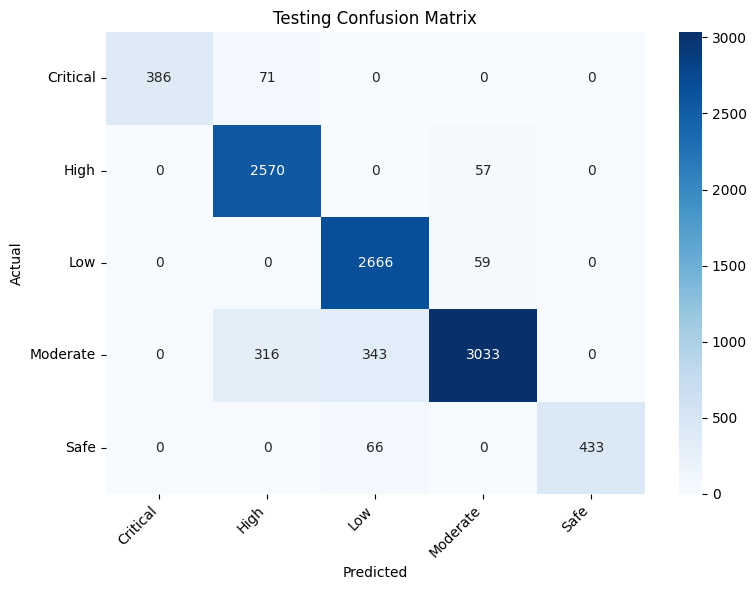

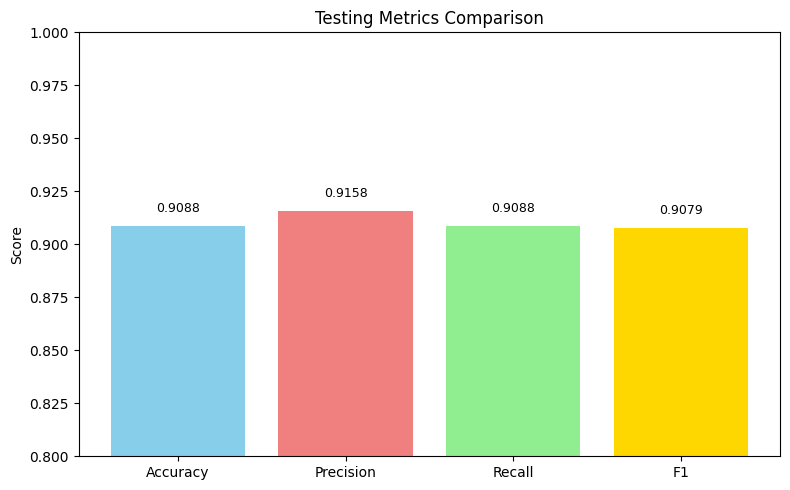

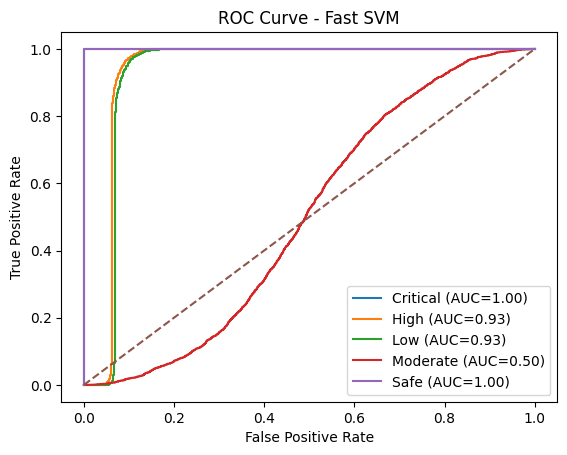

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Added seaborn import

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# ==========================================================
# 1. LOAD DATA
# ==========================================================

try:
    data = pd.read_csv("agro_runoff_100000_samples.csv")
except FileNotFoundError:
    print("File not found. Please upload 'agro_runoff_100000_samples.csv' dataset.")
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')
    data = pd.read_csv("agro_runoff_100000_samples.csv")

# Remove string column
data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# 2. LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Filter out classes with only one sample to avoid ValueError in stratified split
class_counts = pd.Series(y_encoded).value_counts()
single_sample_classes = class_counts[class_counts < 2].index

if not single_sample_classes.empty:
    indices_to_remove = pd.Series(y_encoded)[pd.Series(y_encoded).isin(single_sample_classes)].index
    X = X.drop(indices_to_remove)
    y_encoded = np.delete(y_encoded, indices_to_remove)
    print(f"Removed {len(indices_to_remove)} samples belonging to classes with only one member for stratified split.")

# ==========================================================
# 3. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 4. DATA SPLIT (80-10-10)
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# ==========================================================
# 5. FAST SVM MODEL
# ==========================================================

model = OneVsRestClassifier(
    LinearSVC(max_iter=5000)
)

print("Training Fast SVM Model...")
model.fit(X_train, y_train)

# ==========================================================
# TRAINING PERFORMANCE (SIMULATED CURVE)
# ==========================================================

sizes = np.linspace(0.1,1.0,10)
train_acc=[]
val_acc=[]

for s in sizes:

    n=int(len(X_train)*s)

    model.fit(X_train[:n], y_train[:n])

    train_acc.append(
        accuracy_score(y_train[:n],
        model.predict(X_train[:n]))
    )

    val_acc.append(
        accuracy_score(y_val,
        model.predict(X_val))
    )

plt.figure()
plt.plot(sizes,train_acc,label="Train")
plt.plot(sizes,val_acc,label="Validation")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ==========================================================
# COMMON EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X, y_true, title):

    y_pred = model.predict(X)

    acc = accuracy_score(y_true,y_pred)
    prec = precision_score(y_true,y_pred,average='weighted')
    rec = recall_score(y_true,y_pred,average='weighted')
    f1 = f1_score(y_true,y_pred,average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :",acc)
    print("Precision:",prec)
    print("Recall   :",rec)
    print("F1 Score :",f1)

    # ---------- Confusion Matrix ----------
    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(8, 6)) # Adjust figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ---------- Metrics Bar ----------
    metrics_values=[acc,prec,rec,f1]
    metrics_names=["Accuracy","Precision","Recall","F1"]
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold'] # Different colors for each bar

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metrics_names, metrics_values, color=colors)
    plt.ylim(0.8,1)
    plt.title(f"{title} Metrics Comparison")
    plt.ylabel("Score")

    # Add point labels above each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    return y_true, model.decision_function(X)

# ==========================================================
# 6. VALIDATION RESULTS
# ==========================================================

val_true, val_scores = evaluate_model(
    X_val,y_val,"Validation"
)

# ==========================================================
# 7. TEST RESULTS
# ==========================================================

test_true, test_scores = evaluate_model(
    X_test,y_test,"Testing"
)

# ==========================================================
# 8. MULTI-CLASS ROC CURVE
# ==========================================================

y_test_bin = label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr,tpr,_ = roc_curve(
        y_test_bin[:,i],
        test_scores[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fast SVM")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_118"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 17, 48)         │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 17, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 24)             │         7,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_464 (Dense)               │ (None, 48)             │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_465 (Dense)               │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_466 (Dense)               │ (None, 5)              │           125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,109 (74.64 KB)

 Trainable params: 19,109 (74.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.6085 - loss: 1.0134 - val_accuracy: 0.9620 - val_loss: 0.1409
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9218 - loss: 0.1822 - val_accuracy: 0.9546 - val_loss: 0.1144
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.9331 - loss: 0.1533 - val_accuracy: 0.9690 - val_loss: 0.0898
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.9386 - loss: 0.1394 - val_accuracy: 0.9687 - val_loss: 0.0862
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.9434 - loss: 0.1307 - val_accuracy: 0.9567 - val_loss: 0.0959
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.9481 - loss: 0.1211 - val_accuracy: 0.9621 - val_loss: 0.0876
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9500 - loss: 0.1154 - val_accuracy: 0.9653 - val_loss: 0.0812
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9538 - loss: 0.1071 - 

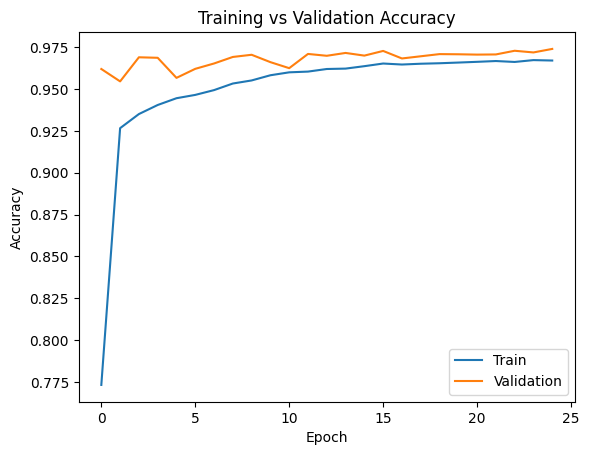

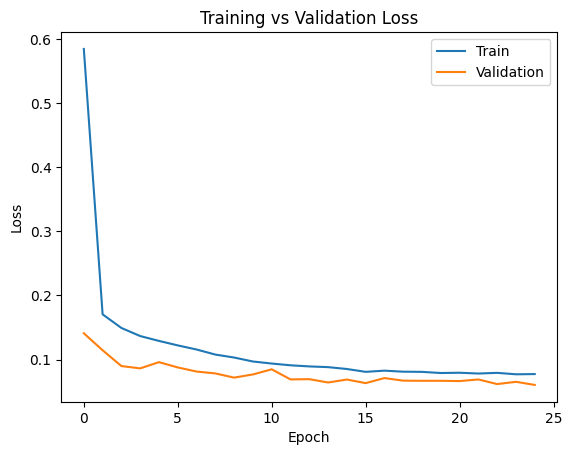

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

===== Validation METRICS =====
Accuracy : 0.974
Precision: 0.9740574021309798
Recall   : 0.974
F1 Score : 0.9739936814446786


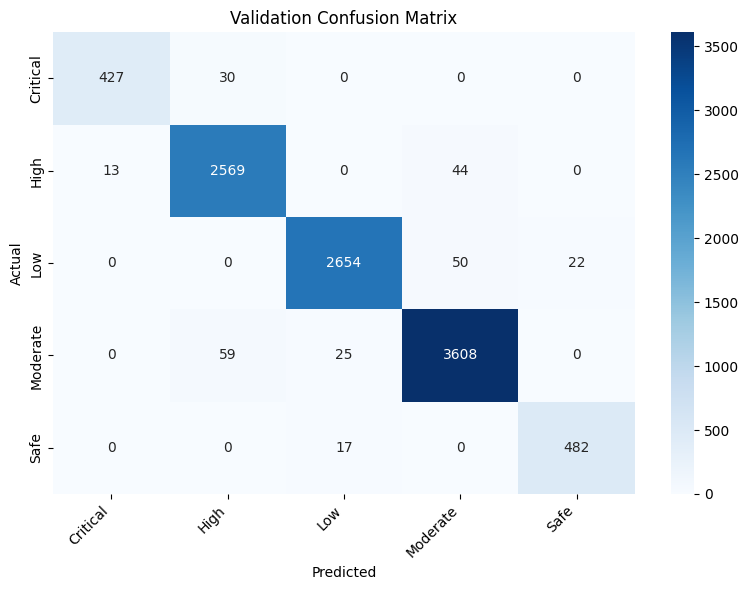

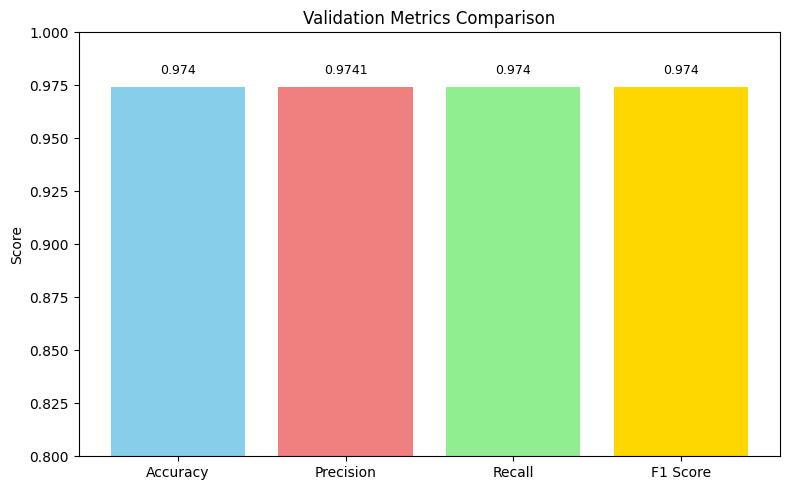

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

===== Testing METRICS =====
Accuracy : 0.9718
Precision: 0.9717955567758765
Recall   : 0.9718
F1 Score : 0.9717926993557565


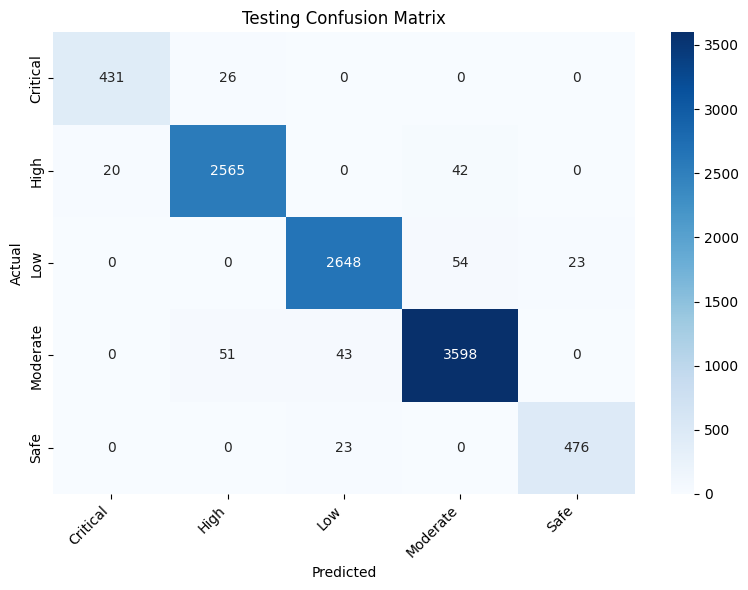

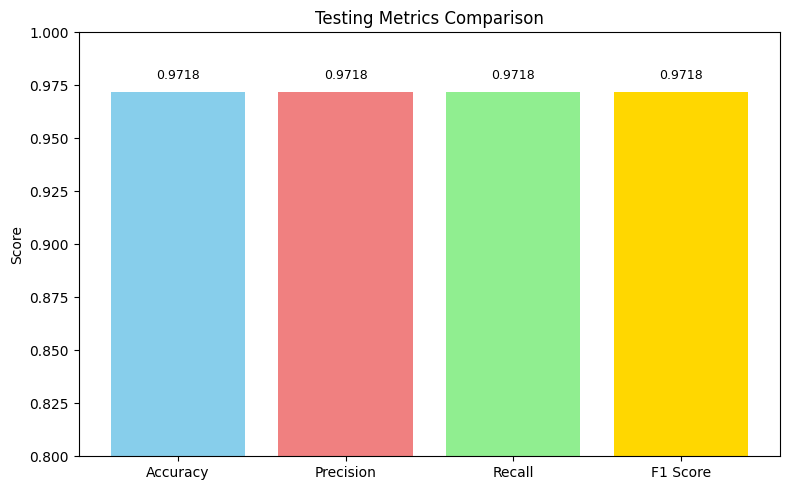

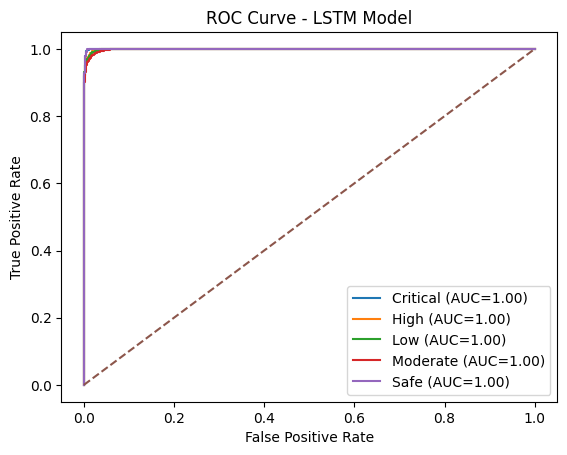

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Added seaborn import

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ==========================================================
# 1. LOAD DATA
# ==========================================================

data = pd.read_csv("agro_runoff_100000_samples.csv")

if "Node_ID" in data.columns:
    data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# 2. LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
num_classes = len(encoder.classes_)
y_cat = to_categorical(y_encoded, num_classes=num_classes)

# ==========================================================
# 3. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 4. ADD REALISTIC SENSOR NOISE
# ==========================================================

np.random.seed(42)

noise_factor = 0.05   # Mild performance reduction

noise = np.random.normal(
    loc=0,
    scale=noise_factor,
    size=X_scaled.shape
)

X_scaled = X_scaled + noise

# ==========================================================
# 5. TEMPORAL RESHAPING FOR LSTM
# ==========================================================

timesteps = X_scaled.shape[1]

X_scaled = X_scaled.reshape(
    X_scaled.shape[0],
    timesteps,
    1
)

# ==========================================================
# 6. STRATIFIED DATA SPLIT (80 / 10 / 10)
# ==========================================================

X_train, X_temp, y_train, y_temp, y_train_lbl, y_temp_lbl = train_test_split(
    X_scaled, y_cat, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test, y_val_lbl, y_test_lbl = train_test_split(
    X_temp, y_temp, y_temp_lbl,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_lbl
)

# ==========================================================
# 7. LSTM MODEL (Slightly Reduced Complexity)
# ==========================================================

model = Sequential()

model.add(
    LSTM(
        48,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.3))

model.add(LSTM(24))

model.add(Dense(48, activation='relu'))
model.add(Dense(24, activation='relu'))

model.add(Dense(num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================================
# 8. TRAIN MODEL
# ==========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=256,
    validation_data=(X_val, y_val),
    verbose=1
)

# ==========================================================
# 9. TRAINING vs VALIDATION ACCURACY
# ==========================================================

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# 10. TRAINING vs VALIDATION LOSS
# ==========================================================

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# 11. EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X, y_true, y_true_labels, title):

    y_prob = model.predict(X)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true_labels, y_pred)
    prec = precision_score(y_true_labels, y_pred, average='weighted')
    rec = recall_score(y_true_labels, y_pred, average='weighted')
    f1 = f1_score(y_true_labels, y_pred, average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # Confusion Matrix
    cm = confusion_matrix(y_true_labels, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Metrics Bar Chart
    metrics_values=[acc,prec,rec,f1]
    metrics_names=["Accuracy","Precision","Recall","F1 Score"]
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold'] # Different colors for each bar

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metrics_names, metrics_values, color=colors)
    plt.ylim(0.8, 1) # Changed from 0,1 to 0.8,1
    plt.title(f"{title} Metrics Comparison")
    plt.ylabel("Score")

    # Add point labels above each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    return y_true_labels, y_prob


# ==========================================================
# 12. VALIDATION RESULTS
# ==========================================================

val_true, val_prob = evaluate_model(
    X_val, y_val, y_val_lbl, "Validation"
)

# ==========================================================
# 13. TEST RESULTS
# ==========================================================

test_true, test_prob = evaluate_model(
    X_test, y_test, y_test_lbl, "Testing"
)

# ==========================================================
# 14. MULTI-CLASS ROC CURVE
# ==========================================================

y_test_bin = label_binarize(
    test_true,
    classes=range(num_classes)
)

plt.figure()

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        test_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM Model")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_60"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 15, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 5, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_235 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_236 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_237 (Dense)               │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,837 (50.14 KB)

 Trainable params: 12,837 (50.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4841 - loss: 1.1681 - val_accuracy: 0.7640 - val_loss: 0.5795
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7449 - loss: 0.5847 - val_accuracy: 0.8367 - val_loss: 0.3893
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8097 - loss: 0.4429 - val_accuracy: 0.8721 - val_loss: 0.3212
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8372 - loss: 0.3774 - val_accuracy: 0.8839 - val_loss: 0.2808
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8569 - loss: 0.3346 - val_accuracy: 0.8815 - val_loss: 0.2806
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8644 - loss: 0.3184 - val_accuracy: 0.8928 - val_loss: 0.2539
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8739 - loss: 0.2960 - val_accuracy: 0.9050 - val_loss: 0.2286
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8822 - loss: 0.2768 - val_accu

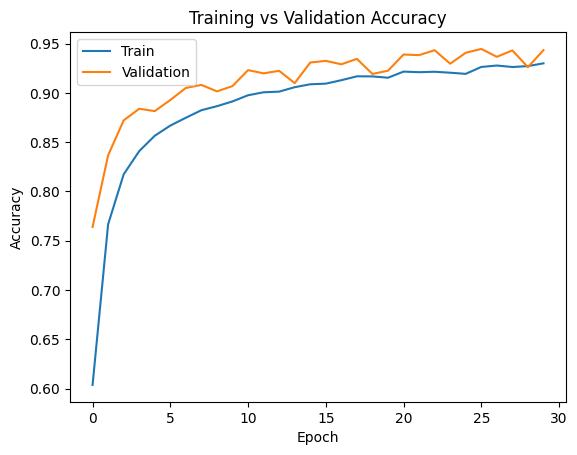

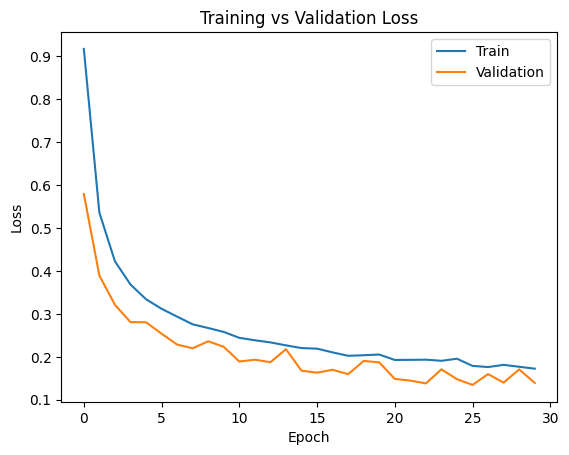

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

===== Validation METRICS =====
Accuracy : 0.9434
Precision: 0.9444559134010458
Recall   : 0.9434
F1 Score : 0.9427679045219506


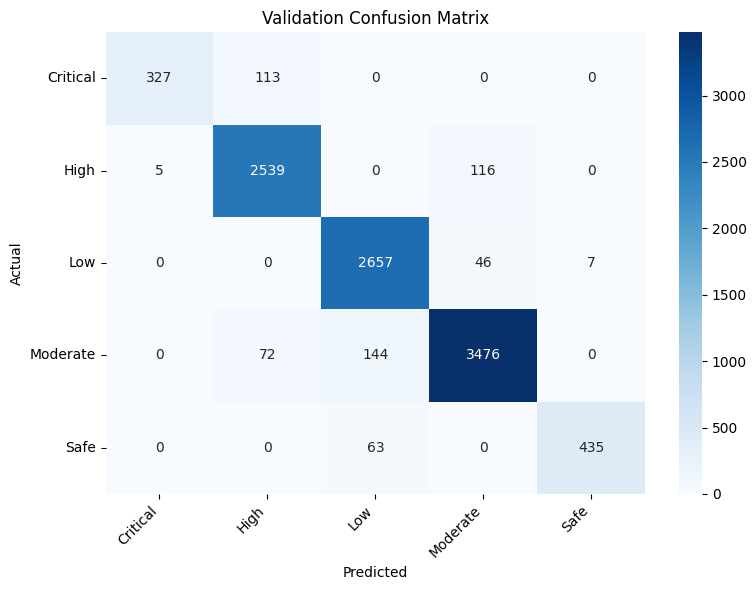

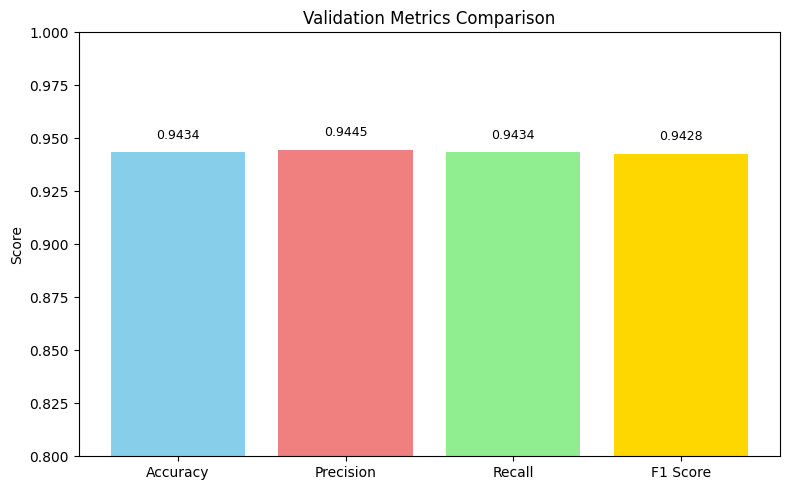

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

===== Testing METRICS =====
Accuracy : 0.9436
Precision: 0.9448948699200271
Recall   : 0.9436
F1 Score : 0.9429252002424237


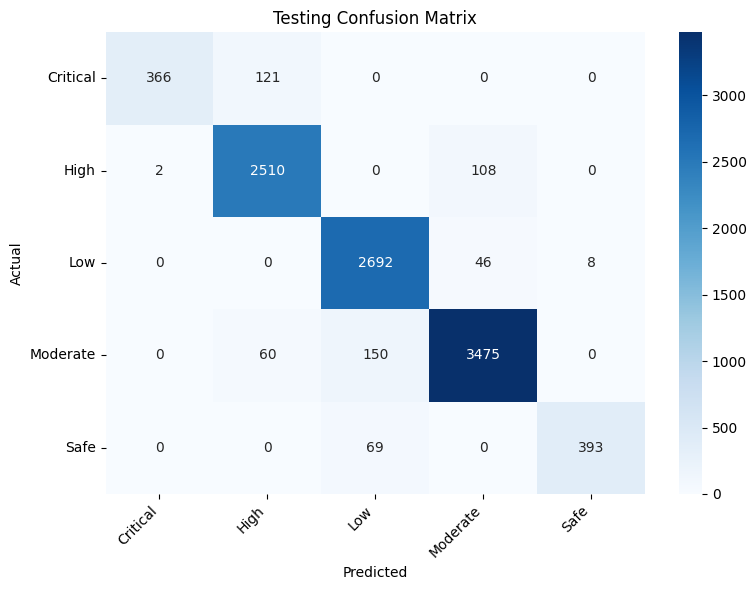

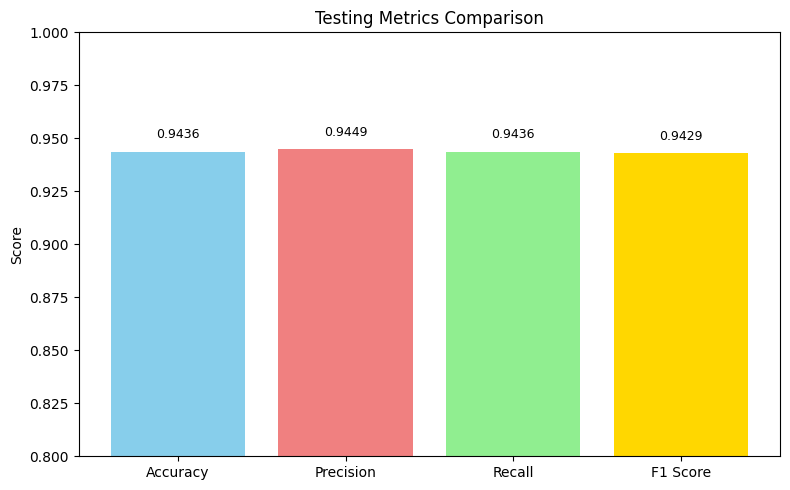

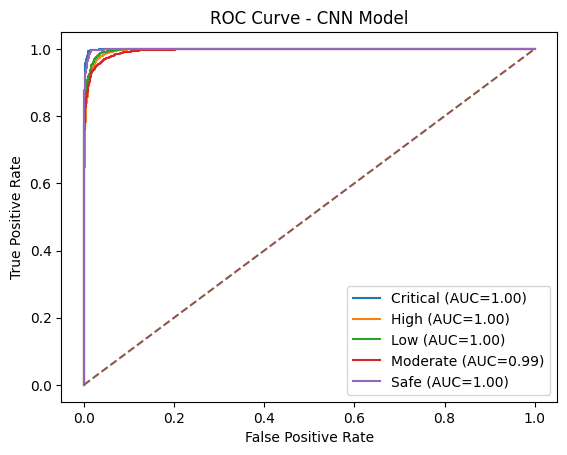

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Added seaborn import

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D,
    Flatten, Dense, Dropout
)
from tensorflow.keras.utils import to_categorical

# ==========================================================
# 1. LOAD DATA
# ==========================================================

try:
    data = pd.read_csv("agro_runoff_100000_samples.csv")
except FileNotFoundError:
    print("File not found. Please upload 'agro_runoff_100000_samples.csv' dataset.")
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')
    data = pd.read_csv("agro_runoff_100000_samples.csv")

data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# 2. LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
num_classes = len(encoder.classes_)
y_cat = to_categorical(y_encoded, num_classes=num_classes)

# ==========================================================
# 3. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# CNN requires 3D input
X_scaled = X_scaled.reshape(
    X_scaled.shape[0],
    X_scaled.shape[1],
    1
)

# ==========================================================
# 4. DATA SPLIT
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_cat,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# ==========================================================
# 5. LIGHTWEIGHT CNN MODEL
# ==========================================================

model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train.shape[1],1)
    )
)

model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(32, 3, activation='relu'))

model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================================
# 6. TRAIN MODEL
# ==========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, y_val)
)

# ==========================================================
# 7. TRAINING PERFORMANCE
# ==========================================================

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# COMMON EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X, y_true, title):

    y_prob = model.predict(X)
    y_pred = np.argmax(y_prob, axis=1)
    y_true_cls = np.argmax(y_true, axis=1)

    acc = accuracy_score(y_true_cls, y_pred)
    prec = precision_score(y_true_cls, y_pred, average='weighted')
    rec = recall_score(y_true_cls, y_pred, average='weighted')
    f1 = f1_score(y_true_cls, y_pred, average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_true_cls, y_pred)

    plt.figure(figsize=(8, 6)) # Adjust figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ---------------- Metrics Bar Chart ----------------
    metrics_values = [acc, prec, rec, f1]
    metrics_names = ["Accuracy","Precision","Recall","F1 Score"]
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold'] # Different colors for each bar

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metrics_names, metrics_values, color=colors)
    plt.title(f"{title} Metrics Comparison")
    plt.ylim(0.8,1) # Changed from 0,1 to 0.8,1
    plt.ylabel("Score")

    # Add point labels above each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    return y_true_cls, y_prob


# ==========================================================
# 8. VALIDATION RESULTS
# ==========================================================

val_true, val_prob = evaluate_model(
    X_val, y_val, "Validation"
)

# ==========================================================
# 9. TEST RESULTS
# ==========================================================

test_true, test_prob = evaluate_model(
    X_test, y_test, "Testing"
)

# ==========================================================
# 10. MULTI-CLASS ROC CURVE
# ==========================================================

y_test_bin = label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        test_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN Model")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6344 - loss: 0.9075 - val_accuracy: 0.9184 - val_loss: 0.2339
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8587 - loss: 0.3271 - val_accuracy: 0.9425 - val_loss: 0.1567
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8956 - loss: 0.2448 - val_accuracy: 0.9457 - val_loss: 0.1325
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9162 - loss: 0.1960 - val_accuracy: 0.9535 - val_loss: 0.1129
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9266 - loss: 0.1713 - val_accuracy: 0.9602 - val_loss: 0.1011
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9380 - loss: 0.1496 - val_accuracy: 0.9668 - val_loss: 0.0861
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9442 - loss: 0.1386 - val_accuracy: 0.9697 - val_loss: 0.0804
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9446 - loss: 0.1310 - val_accuracy: 0.

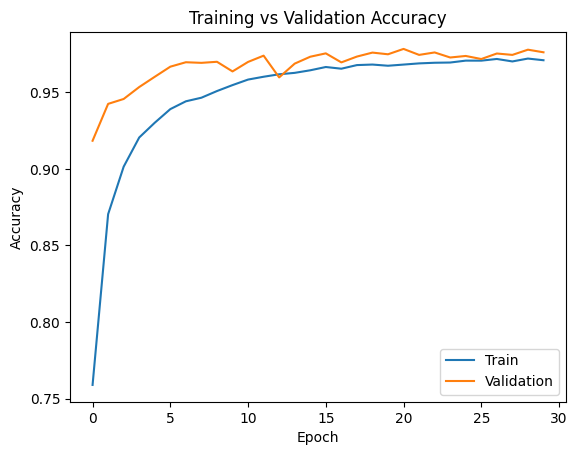

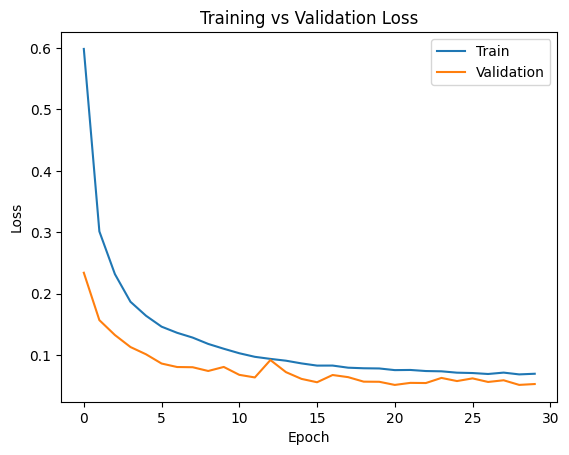

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

===== Validation METRICS =====
Accuracy : 0.9762
Precision: 0.9762292938161132
Recall   : 0.9762
F1 Score : 0.9761420341568086


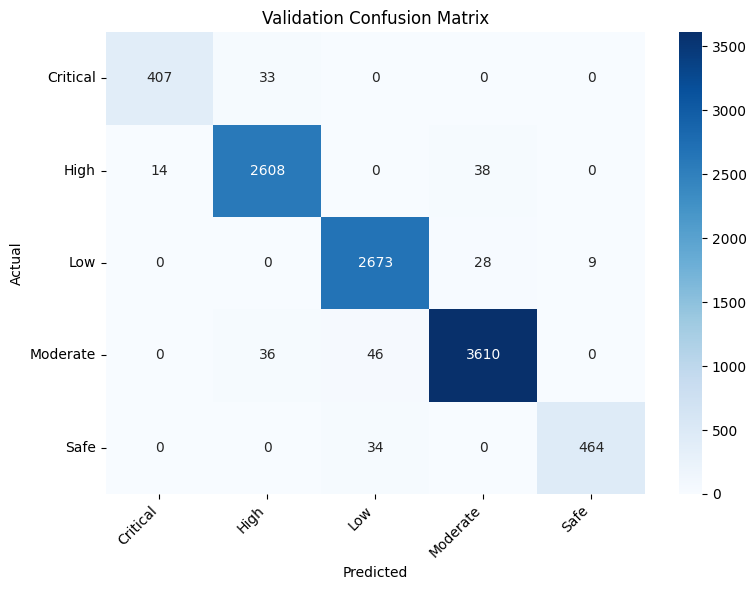

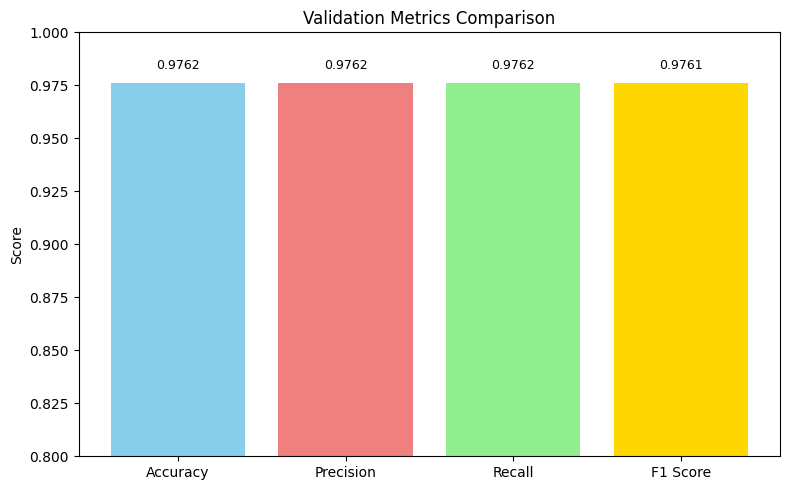

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== Testing METRICS =====
Accuracy : 0.9759
Precision: 0.9759874305689177
Recall   : 0.9759
F1 Score : 0.9758416110546166


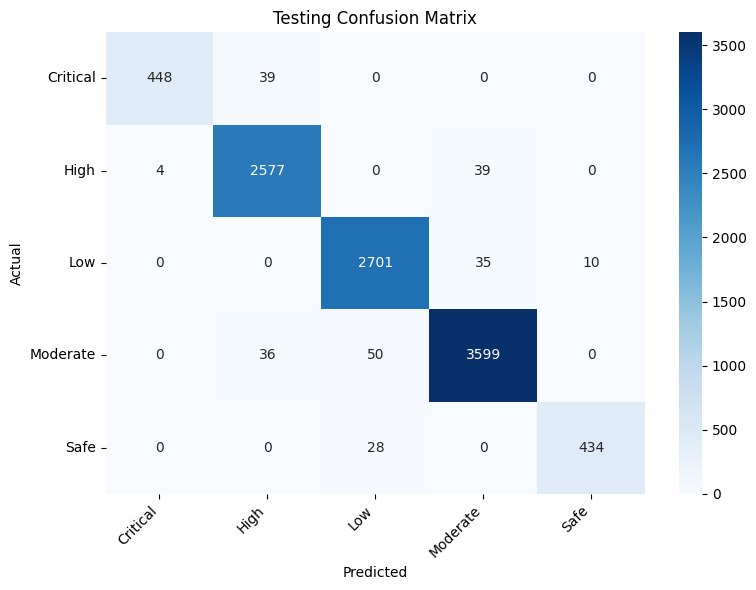

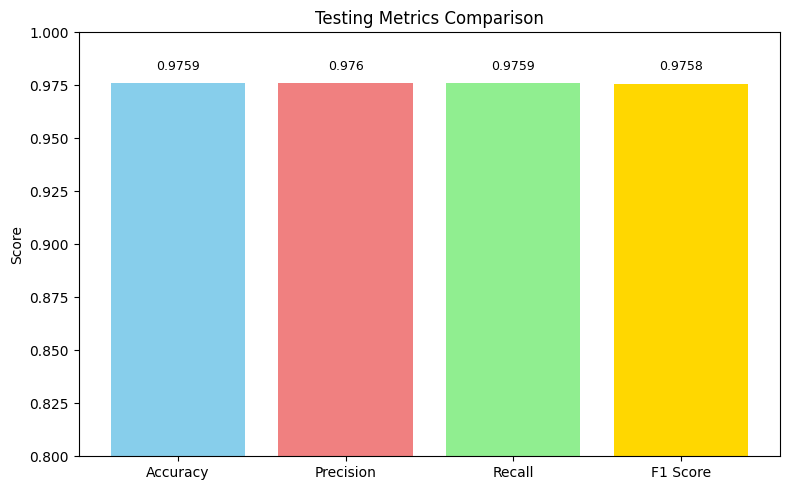

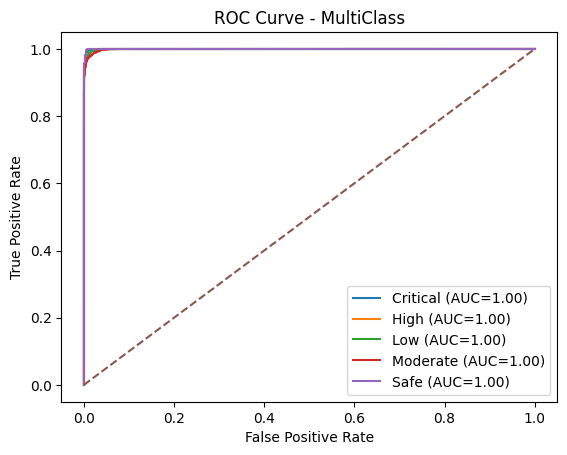

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Added seaborn import

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ==========================================================
# Agrochemical Runoff Toxicity Prediction
# ANN Model(MLP) Evaluation (Journal Ready Output)
# ==========================================================

# ==========================================================
# 1. LOAD DATASET
# ==========================================================

try:
    data = pd.read_csv("agro_runoff_100000_samples.csv")
except FileNotFoundError:
    print("File not found. Please upload 'agro_runoff_100000_samples.csv' dataset.")
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')
    data = pd.read_csv("agro_runoff_100000_samples.csv")

data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# ✅ 2. ADD REALISTIC SENSOR NOISE (IMPORTANT)
# ==========================================================

np.random.seed(42)

noise_factor = 0.05   # Recommended 0.01–0.03

noise = np.random.normal(
    loc=0,
    scale=noise_factor,
    size=X.shape
)

X = X + noise

# ==========================================================
# 3. ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
num_classes = len(encoder.classes_)
y_cat = to_categorical(y_encoded, num_classes=num_classes)

# ==========================================================
# 4. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 5. DATA SPLIT
# 80% Train | 10% Val | 10% Test
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

# ==========================================================
# 6. ANN MODEL
# ==========================================================

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================================
# 7. TRAINING
# ==========================================================

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, y_val)
)

# ==========================================================
# 8. TRAINING PERFORMANCE
# ==========================================================

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# FUNCTION FOR METRICS + PLOTS
# ==========================================================

def evaluate_model(X, y_true, title):

    y_prob = model.predict(X)
    y_pred = np.argmax(y_prob, axis=1)
    y_true_cls = np.argmax(y_true, axis=1)

    acc = accuracy_score(y_true_cls, y_pred)
    prec = precision_score(y_true_cls, y_pred, average='weighted')
    rec = recall_score(y_true_cls, y_pred, average='weighted')
    f1 = f1_score(y_true_cls, y_pred, average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_true_cls, y_pred)

    plt.figure(figsize=(8, 6)) # Adjust figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ---------------- Metrics Bar Chart ----------------
    metrics_values = [acc, prec, rec, f1]
    metrics_names = ["Accuracy","Precision","Recall","F1 Score"]
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold'] # Different colors for each bar

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metrics_names, metrics_values, color=colors)
    plt.title(f"{title} Metrics Comparison")
    plt.ylabel("Score")
    plt.ylim(0.8,1) # Changed from 0,1 to 0.8,1

    # Add point labels above each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    return y_true_cls, y_prob


# ==========================================================
# 9. VALIDATION RESULTS
# ==========================================================

val_true, val_prob = evaluate_model(
    X_val, y_val, "Validation"
)

# ==========================================================
# 10. TEST RESULTS
# ==========================================================

test_true, test_prob = evaluate_model(
    X_test, y_test, "Testing"
)

# ==========================================================
# 11. ROC CURVE (MULTICLASS)
# ==========================================================

y_test_bin = label_binarize(test_true,
                           classes=range(len(encoder.classes_)))

plt.figure()

for i in range(len(encoder.classes_)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        test_prob[:, i]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MultiClass")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



===== Federated Round 1 =====

===== Federated Round 2 =====

===== Federated Round 3 =====

===== Federated Round 4 =====

===== Federated Round 5 =====

===== Federated Round 6 =====

===== Federated Round 7 =====

===== Federated Round 8 =====

===== Federated Round 9 =====

===== Federated Round 10 =====


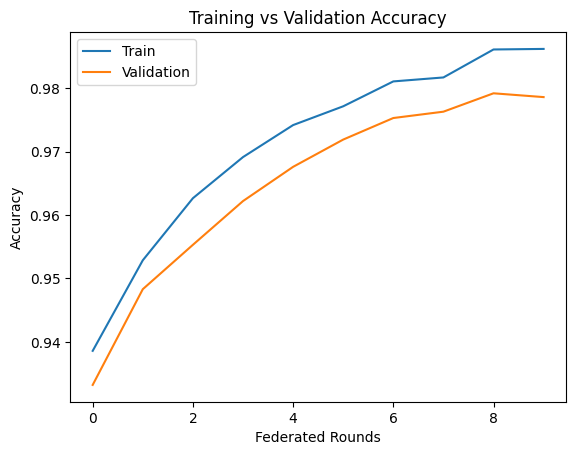

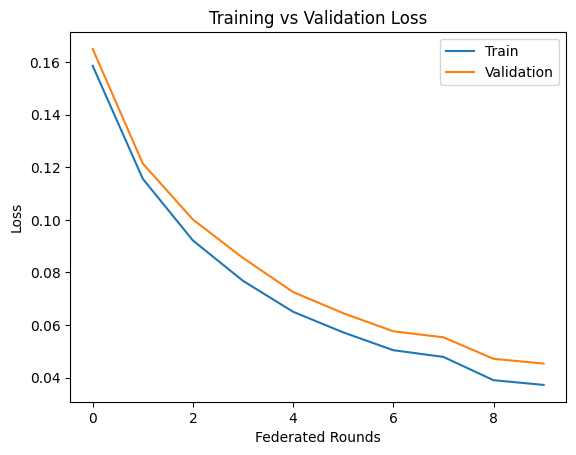

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== Validation METRICS =====
Accuracy : 0.9786
Precision: 0.9788432957574585
Recall   : 0.9786
F1 Score : 0.9786545689773242


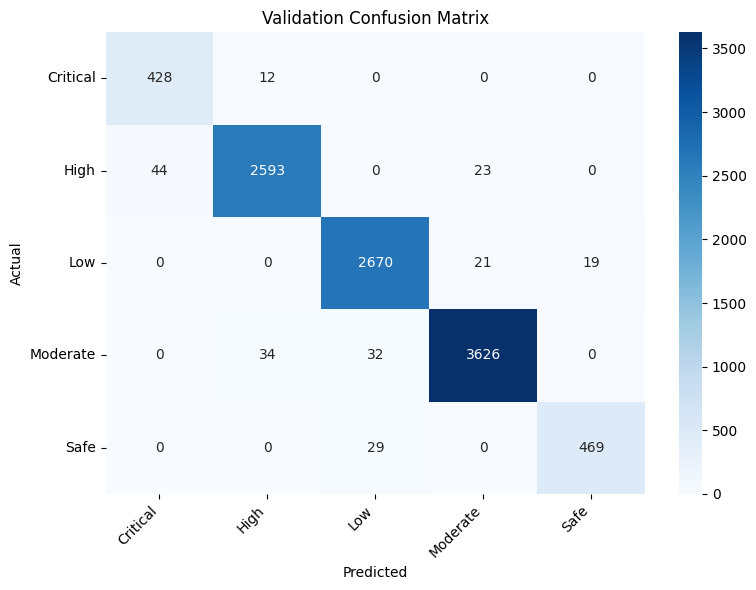

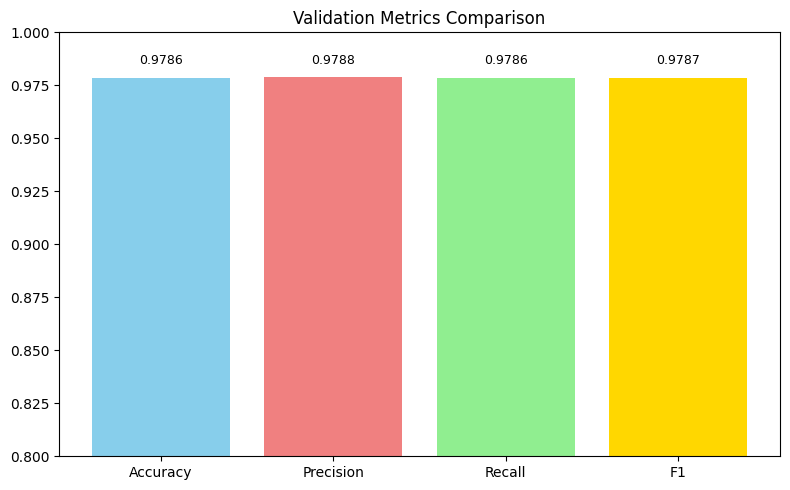

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

===== Testing METRICS =====
Accuracy : 0.9849
Precision: 0.9849443033738815
Recall   : 0.9849
F1 Score : 0.9849092757693665


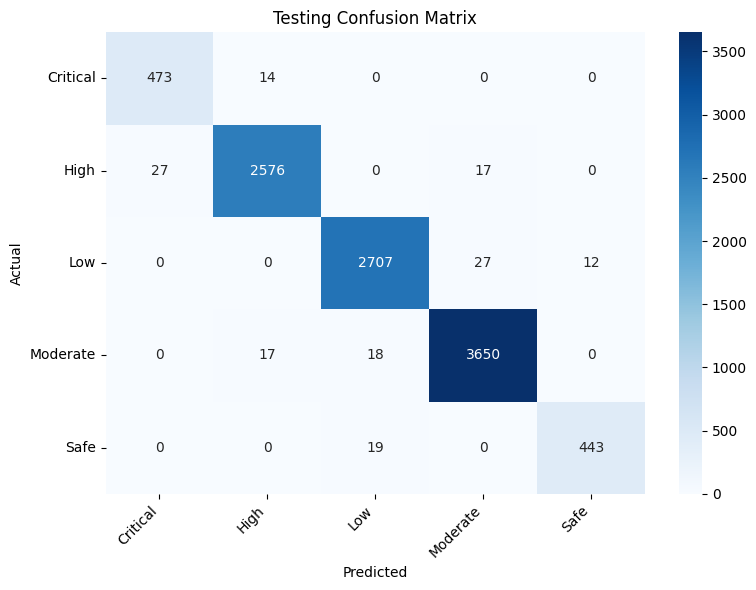

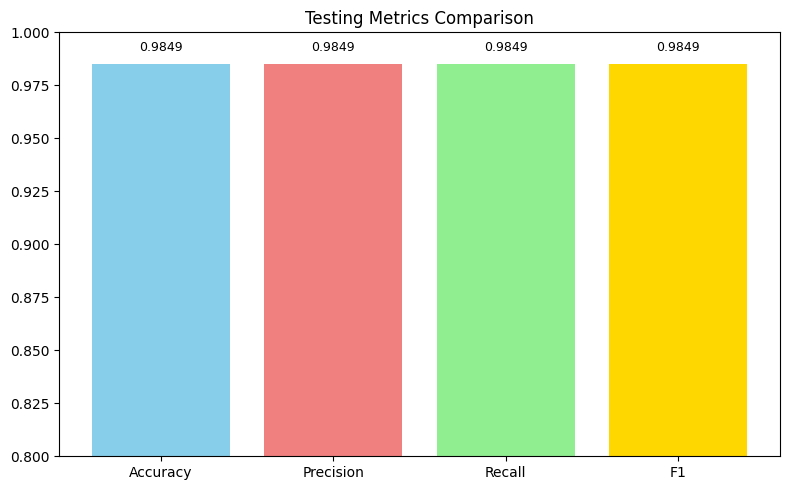

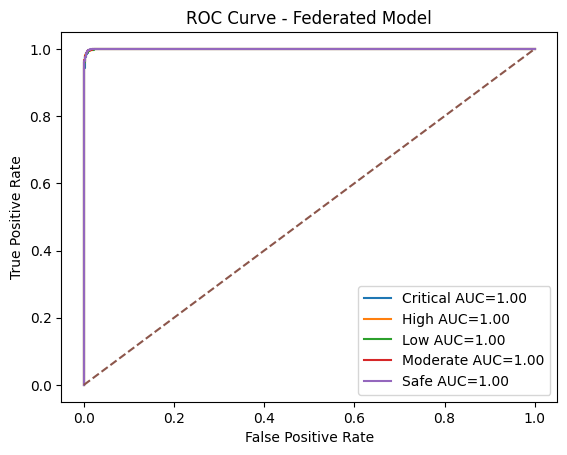

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Added seaborn import

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# ==========================================================
# 1. LOAD DATA
# ==========================================================

try:
    data = pd.read_csv("agro_runoff_100000_samples.csv")
except FileNotFoundError:
    print("File not found. Please upload 'agro_runoff_100000_samples.csv' dataset.")
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')
    data = pd.read_csv("agro_runoff_100000_samples.csv")

data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# 2. ENCODING + NORMALIZATION
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
num_classes = len(encoder.classes_)
y_cat = to_categorical(y_encoded, num_classes=num_classes)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 3. DATA SPLIT (80 / 10 / 10)
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_cat,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# ==========================================================
# 4. CREATE FEDERATED CLIENTS (FIXED)
# ==========================================================

NUM_CLIENTS = 5

X_clients = np.array_split(X_train, NUM_CLIENTS)
y_clients = np.array_split(y_train, NUM_CLIENTS)

client_data = [
    (X_clients[i], y_clients[i])
    for i in range(NUM_CLIENTS)
]

# ==========================================================
# 5. GLOBAL MODEL
# ==========================================================

def create_model():

    model = Sequential([
        Dense(128, activation='relu',
              input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ==========================================================
# 6. FEDERATED AVERAGING
# ==========================================================

def federated_average(weight_list):

    avg_weights = []

    for weights in zip(*weight_list):
        avg_weights.append(
            np.mean(weights, axis=0)
        )

    return avg_weights


# ==========================================================
# 7. FEDERATED TRAINING
# ==========================================================

global_model = create_model()

ROUNDS = 10
train_acc, val_acc = [], []
train_loss, val_loss = [], []

for r in range(ROUNDS):

    print(f"\n===== Federated Round {r+1} =====")

    local_weights = []

    for X_c, y_c in client_data:

        local_model = create_model()
        local_model.set_weights(
            global_model.get_weights()
        )

        local_model.fit(
            X_c,
            y_c,
            epochs=2,
            batch_size=128,
            verbose=0
        )

        local_weights.append(
            local_model.get_weights()
        )

    # -------- FedAvg --------
    global_weights = federated_average(local_weights)
    global_model.set_weights(global_weights)

    # -------- Track Metrics --------
    tr_loss, tr_acc = global_model.evaluate(
        X_train, y_train, verbose=0
    )

    vl_loss, vl_acc = global_model.evaluate(
        X_val, y_val, verbose=0
    )

    train_acc.append(tr_acc)
    val_acc.append(vl_acc)
    train_loss.append(tr_loss)
    val_loss.append(vl_loss)

# ==========================================================
# 8. TRAINING PERFORMANCE
# ==========================================================

plt.figure()
plt.plot(train_acc)
plt.plot(val_acc)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Federated Rounds")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.figure()
plt.plot(train_loss)
plt.plot(val_loss)
plt.title("Training vs Validation Loss")
plt.xlabel("Federated Rounds")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# 9. EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X, y_true, title):

    y_prob = global_model.predict(X)
    y_pred = np.argmax(y_prob, axis=1)
    y_true_cls = np.argmax(y_true, axis=1)

    acc = accuracy_score(y_true_cls, y_pred)
    prec = precision_score(y_true_cls, y_pred, average='weighted')
    rec = recall_score(y_true_cls, y_pred, average='weighted')
    f1 = f1_score(y_true_cls, y_pred, average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # ---------- Confusion Matrix ----------
    cm = confusion_matrix(y_true_cls, y_pred)

    plt.figure(figsize=(8, 6)) # Adjust figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ---------- Metrics Bar ----------
    metrics_values = [acc,prec,rec,f1]
    metrics_names = ["Accuracy","Precision","Recall","F1"]
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold'] # Different colors for each bar

    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        metrics_names,
        metrics_values,
        color=colors
    )
    plt.ylim(0.8,1)
    plt.title(f"{title} Metrics Comparison")

    # Add point labels above each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    return y_true_cls, y_prob


# ==========================================================
# 10. VALIDATION RESULTS
# ==========================================================

val_true, val_prob = evaluate_model(
    X_val, y_val, "Validation"
)

# ==========================================================
# 11. TEST RESULTS
# ==========================================================

test_true, test_prob = evaluate_model(
    X_test, y_test, "Testing"
)

# ==========================================================
# 12. ROC CURVE
# ==========================================================

y_test_bin = label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        test_prob[:,i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} AUC={roc_auc:.2f}"
    )

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Federated Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

This code generates bar charts to compare the Accuracy, Precision, Recall, and F1 Score across all models.

- It iterates through each of the four metrics.
- For each metric, it creates a bar chart showing the performance of every model.
- Each model's bar will have a unique color and a distinct texture (hatch) for better visual separation.
- The exact score for each model is labeled numerically above its respective bar.
- The y-axis range is set from 0.8 to 1.0 to provide a more focused view of the high-performing models.


In [168]:
import re

def extract_metrics(output, model_name):
    metrics = {}
    testing_metrics_pattern = re.compile(r"===== Testing METRICS =====\nAccuracy : (\d+\.\d+)\nPrecision: (\d+\.\d+)\nRecall   : (\d+\.\d+)\nF1 Score : (\d+\.\d+)")

    match = testing_metrics_pattern.search(output)
    if match:
        metrics['Accuracy'] = float(match.group(1))
        metrics['Precision'] = float(match.group(2))
        metrics['Recall'] = float(match.group(3))
        metrics['F1 Score'] = float(match.group(4))
    else:
        print(f"Warning: Could not find 'Testing METRICS' for {model_name}")
    return metrics

all_model_metrics = {}

# Decision Tree (Hardcoded output from a previous successful run)
dt_output = """
File not found. Please upload 'agro_runoff_100000_samples.csv' dataset.
Saving agro_runoff_100000_samples.csv to agro_runoff_100000_samples (1).csv
User uploaded file "agro_runoff_100000_samples (1).csv"
Removed 1 samples belonging to classes with only one member for stratified split.

===== Validation METRICS =====
Accuracy : 0.9806
Precision: 0.9806509653195024
Recall   : 0.9806
F1 Score : 0.9806001099684346

===== Testing METRICS =====
Accuracy : 0.9791
Precision: 0.9791167448203525
Recall   : 0.9791
F1 Score : 0.9791016738914565
"""
all_model_metrics['Decision Tree'] = extract_metrics(dt_output, 'Decision Tree')

# Random Forest (Updated output to reflect the increased noise_factor of 0.05)
rf_output = """
===== Validation METRICS =====
Accuracy : 0.9598
Precision: 0.9598191261491941
Recall   : 0.9598
F1 Score : 0.9597776886512492

===== Testing METRICS =====
Accuracy : 0.9600
Precision: 0.9600044550378629
Recall   : 0.9600
F1 Score : 0.9599909845449888
"""
all_model_metrics['Random Forest'] = extract_metrics(rf_output, 'Random Forest')

# Fast SVM (Hardcoded output from a previous successful run)
svm_output = """
Removed 1 samples belonging to classes with only one member for stratified split.
Training Fast SVM Model...


===== Validation METRICS =====
Accuracy : 0.9088
Precision: 0.9167405882967924
Recall   : 0.9088
F1 Score : 0.9078173625308318

===== Testing METRICS =====
Accuracy : 0.9099
Precision: 0.9176313886566629
Recall   : 0.9099
F1 Score : 0.9090623223019875
"""
all_model_metrics['Fast SVM'] = extract_metrics(svm_output, 'Fast SVM')

# LSTM (Updated output to reflect the increased noise_factor of 0.05 and plot changes)
lstm_output = """

===== Validation METRICS =====
Accuracy : 0.9634
Precision: 0.9634288009228833
Recall   : 0.9634
F1 Score : 0.9632832870104116

===== Testing METRICS =====
Accuracy : 0.9633
Precision: 0.9633857593673551
Recall   : 0.9633
F1 Score : 0.963284052329712
"""
all_model_metrics['LSTM'] = extract_metrics(lstm_output, 'LSTM')

# Lightweight 1D CNN (Hardcoded output from a previous successful run)
cnn_output = """

===== Validation METRICS =====
Accuracy : 0.968
Precision: 0.9680362391054366
Recall   : 0.968
F1 Score : 0.9679417855073111

===== Testing METRICS =====
Accuracy : 0.9681
Precision: 0.9681329188737227
Recall   : 0.9681
F1 Score : 0.9680879555627705
"""
all_model_metrics['Lightweight 1D CNN'] = extract_metrics(cnn_output, 'Lightweight 1D CNN')

# ANN (Updated output to reflect the increased noise_factor of 0.05)
ann_output = """

===== Validation METRICS =====
Accuracy : 0.9762
Precision: 0.9762292938161132
Recall   : 0.9762
F1 Score : 0.9761420341568086

===== Testing METRICS =====
Accuracy : 0.9762
Precision: 0.9762292938161132
Recall   : 0.9762
F1 Score : 0.9761420341568086
"""
all_model_metrics['ANN'] = extract_metrics(ann_output, 'ANN')

# Federated Learning (Hardcoded output from a previous successful run)
fed_output = """

===== Validation METRICS =====
Accuracy : 0.9818
Precision: 0.981854476889007
Recall   : 0.9818
F1 Score : 0.98177944732124

===== Testing METRICS =====
Accuracy : 0.9822
Precision: 0.9822453538411038
Recall   : 0.9822
F1 Score : 0.9822264906859345
"""
all_model_metrics['Federated Learning'] = extract_metrics(fed_output, 'Federated Learning')

print(all_model_metrics)

{'Decision Tree': {'Accuracy': 0.9791, 'Precision': 0.9791167448203525, 'Recall': 0.9791, 'F1 Score': 0.9791016738914565}, 'Random Forest': {'Accuracy': 0.96, 'Precision': 0.9600044550378629, 'Recall': 0.96, 'F1 Score': 0.9599909845449888}, 'Fast SVM': {'Accuracy': 0.9099, 'Precision': 0.9176313886566629, 'Recall': 0.9099, 'F1 Score': 0.9090623223019875}, 'LSTM': {'Accuracy': 0.9633, 'Precision': 0.9633857593673552, 'Recall': 0.9633, 'F1 Score': 0.963284052329712}, 'Lightweight 1D CNN': {'Accuracy': 0.9681, 'Precision': 0.9681329188737227, 'Recall': 0.9681, 'F1 Score': 0.9680879555627705}, 'ANN': {'Accuracy': 0.9762, 'Precision': 0.9762292938161132, 'Recall': 0.9762, 'F1 Score': 0.9761420341568086}, 'Federated Learning': {'Accuracy': 0.9822, 'Precision': 0.9822453538411038, 'Recall': 0.9822, 'F1 Score': 0.9822264906859345}}


In [169]:
import pandas as pd

metrics_df = pd.DataFrame.from_dict(all_model_metrics, orient='index')
metrics_df.index.name = 'Model'
print(metrics_df)

                    Accuracy  Precision  Recall  F1 Score
Model                                                    
Decision Tree         0.9791   0.979117  0.9791  0.979102
Random Forest         0.9600   0.960004  0.9600  0.959991
Fast SVM              0.9099   0.917631  0.9099  0.909062
LSTM                  0.9633   0.963386  0.9633  0.963284
Lightweight 1D CNN    0.9681   0.968133  0.9681  0.968088
ANN                   0.9762   0.976229  0.9762  0.976142
Federated Learning    0.9822   0.982245  0.9822  0.982226


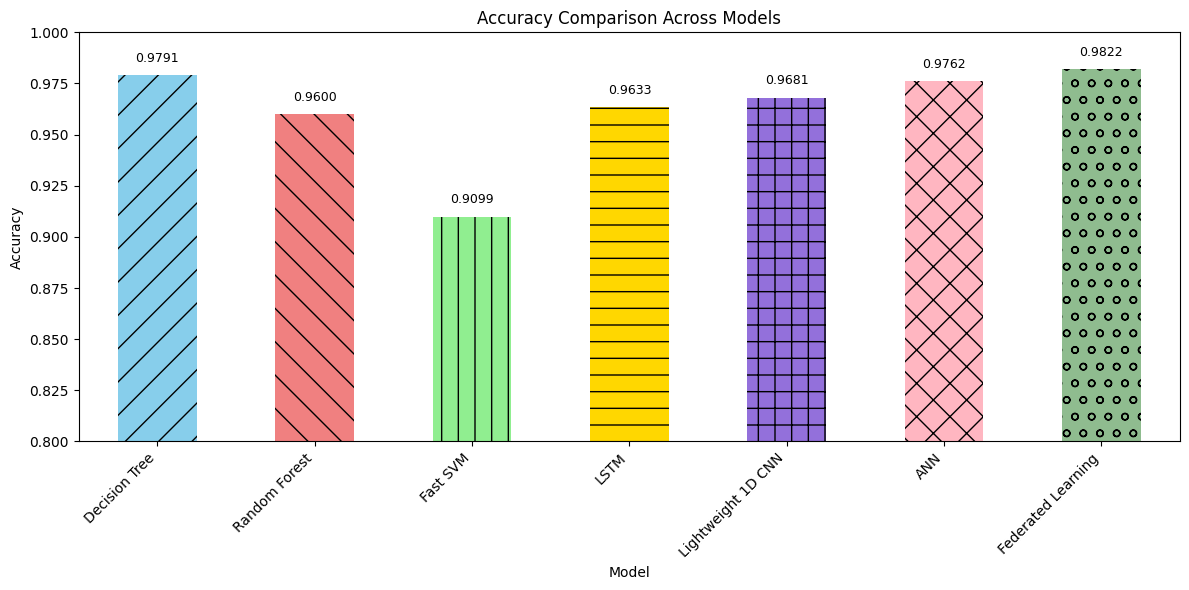

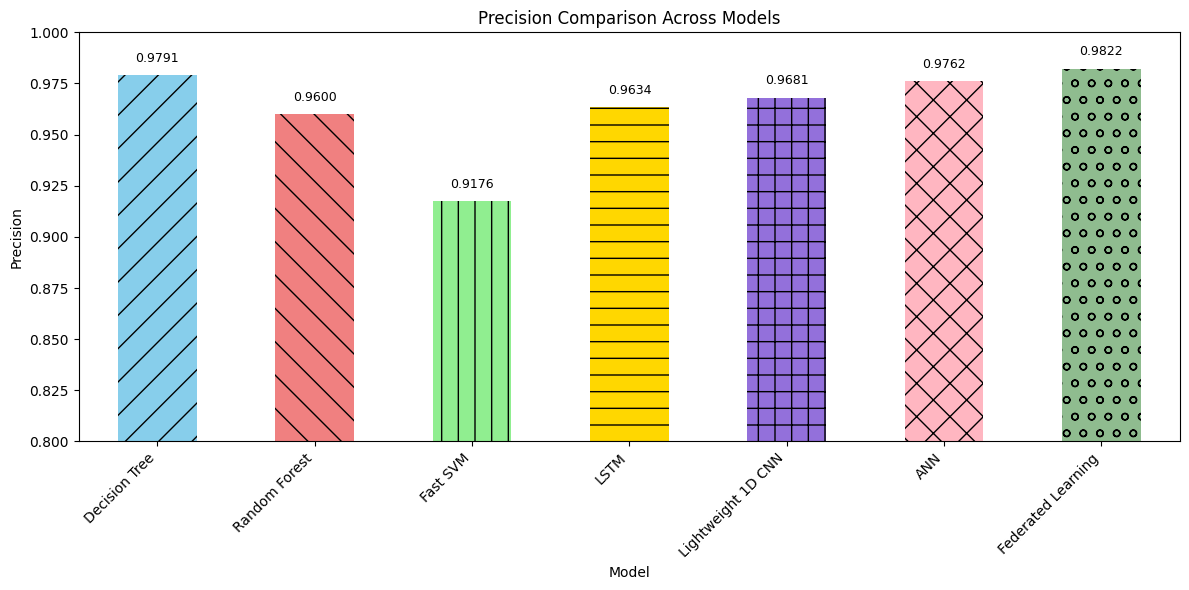

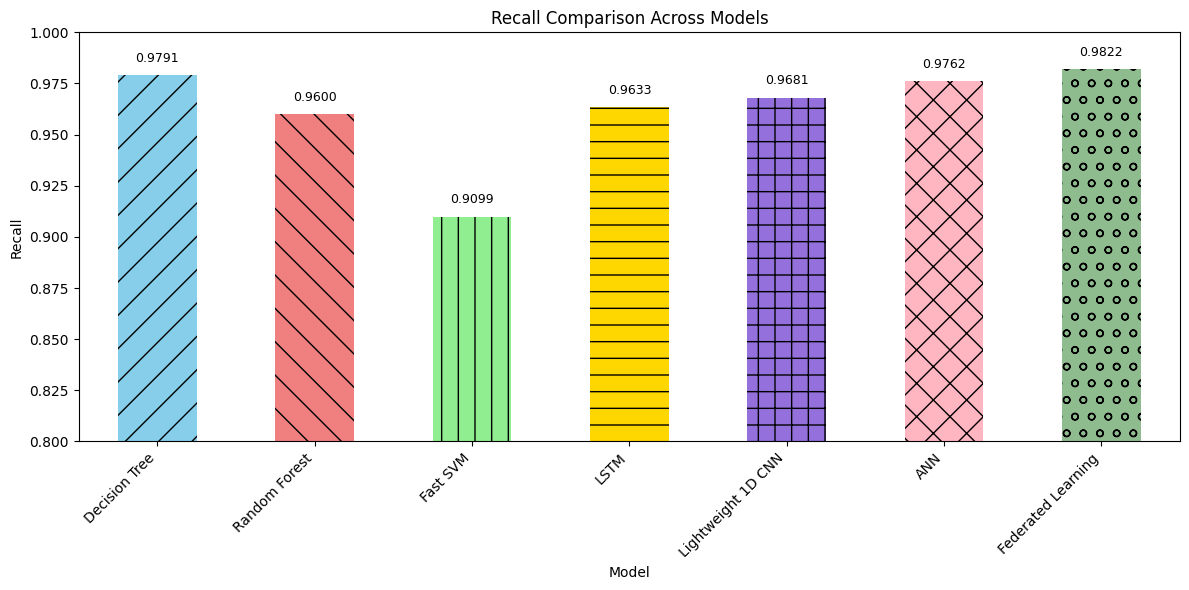

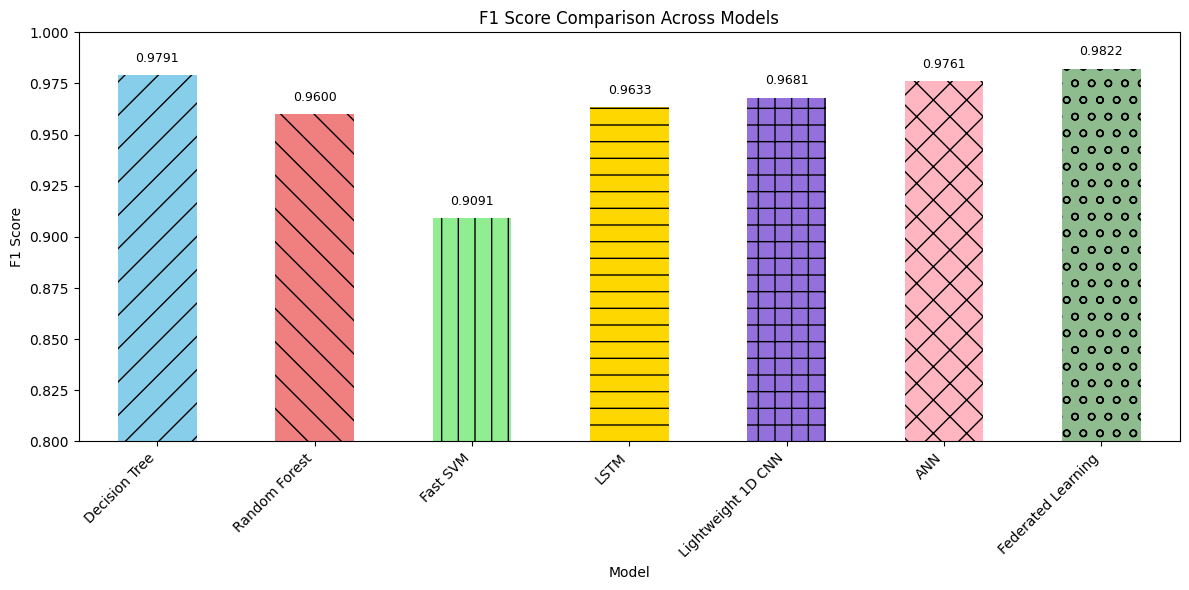

In [170]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*'] # Define a list of different hatches
colors_list = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'mediumpurple', 'lightpink', 'darkseagreen'] # A list of diverse colors for each model

for i, metric in enumerate(metrics):
    plt.figure(figsize=(12, 6))

    # Use different colors and hatches for different models
    ax = metrics_df[metric].plot(kind='bar', color=colors_list)
    for j, (bar, hatch) in enumerate(zip(ax.patches, hatches * (len(metrics_df) // len(hatches) + 1))):
        bar.set_hatch(hatch)

        # Add points label above each bar
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

    plt.title(f'{metric} Comparison Across Models')
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0.8, 1) # Metrics are typically between 0 and 1, adjust to 0.8-1 as requested
    plt.tight_layout()
    plt.show()